# Polynomial Regression으로 Calories_Burned 예측하기

scikit-learn의 `PolynomialFeatures`와 `LinearRegression`을 조합하여 RMSE 최소화

## 1. 라이브러리 임포트

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. 랜덤 시드 고정

In [7]:
import random
import os

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42)

## 3. 데이터 로드

In [8]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain 데이터:")
display(train.head())

Train shape: (7500, 11)
Test shape: (7500, 10)

Train 데이터:


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0


## 4. 데이터 탐색

In [9]:
print('데이터 타입:')
print(train.dtypes)
print(f'\n결측치: {train.isnull().sum().sum()}')
print(f'\n타겟 변수 통계:')
print(train['Calories_Burned'].describe())

데이터 타입:
ID                           object
Exercise_Duration           float64
Body_Temperature(F)         float64
BPM                         float64
Height(Feet)                float64
Height(Remainder_Inches)    float64
Weight(lb)                  float64
Weight_Status                object
Gender                       object
Age                           int64
Calories_Burned             float64
dtype: object

결측치: 0

타겟 변수 통계:
count    7500.000000
mean       89.373467
std        62.817086
min         1.000000
25%        35.000000
50%        77.000000
75%       138.000000
max       300.000000
Name: Calories_Burned, dtype: float64


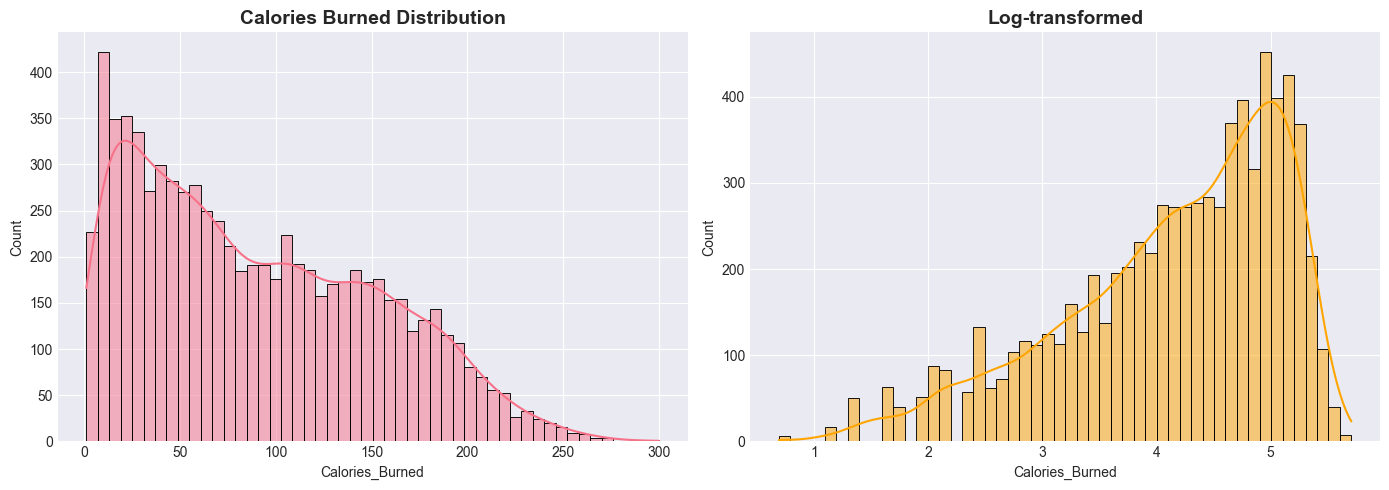

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['Calories_Burned'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Calories Burned Distribution', fontsize=14, fontweight='bold')

sns.histplot(np.log1p(train['Calories_Burned']), bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Log-transformed', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

오른쪽 꼬리 긴 분포 → 로그 변환 필요성 확인

## 5. 데이터 전처리

In [11]:
# ID 제거 및 X, y 분리
train_x = train.drop(['ID', 'Calories_Burned'], axis=1)
train_y = train['Calories_Burned']
test_x = test.drop('ID', axis=1)

print("Train X shape:", train_x.shape)
print("Train y shape:", train_y.shape)
print("Test X shape:", test_x.shape)

Train X shape: (7500, 9)
Train y shape: (7500,)
Test X shape: (7500, 9)


## 6. 범주형 변수 인코딩

In [12]:
# One-Hot Encoding drop_first=True로 다중공선성 방지
train_x = pd.get_dummies(train_x, columns=['Gender', 'Weight_Status'], drop_first=True)
test_x = pd.get_dummies(test_x, columns=['Gender', 'Weight_Status'], drop_first=True)

# 컬럼 맞추기
train_x, test_x = train_x.align(test_x, join='left', axis=1, fill_value=0)
test_x = test_x[train_x.columns]

print("인코딩 후 Train X shape:", train_x.shape)
print("인코딩 후 Test X shape:", test_x.shape)

인코딩 후 Train X shape: (7500, 10)
인코딩 후 Test X shape: (7500, 10)


## 7. 파생 변수 생성 (EDA 기반)


In [13]:
# ========== 파생변수 생성 함수 ==========
def create_features(df):
    """EDA에서 검증된 중요 파생변수 생성"""

    # 1. 총 키 (인치)
    df['Height_Total_Inches'] = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']

    # 2. 체온 차이 (정상 체온 98.6°F 기준)
    df['Temp_diff'] = df['Body_Temperature(F)'] - 98.6

    # 3. 운동 시간 구간화
    df['Duration_bin'] = pd.cut(
        df['Exercise_Duration'],
        bins=[0, 10, 20, 30],
        labels=[0, 1, 2]
    ).astype(int)

    # 4. 운동시간 × BPM (운동 강도)
    df['Duration_x_BPM'] = df['Exercise_Duration'] * df['BPM']

    # 5. 운동시간 × 체온차이
    df['Duration_x_TempDiff'] = df['Exercise_Duration'] * df['Temp_diff']

    # 6. BPM × 체온차이
    df['BPM_x_TempDiff'] = df['BPM'] * df['Temp_diff']

    # 7. 운동시간 제곱 (비선형 관계)
    df['Duration_sq'] = df['Exercise_Duration'] ** 2

    # 8. 체온차이 제곱
    df['Temp_diff_sq'] = df['Temp_diff'] ** 2

    # 9. 3중 상호작용 (운동시간 × BPM × 체온차이)
    df['Dur_BPM_TempDiff'] = df['Exercise_Duration'] * df['BPM'] * df['Temp_diff']

    # 10. BPM / 운동시간 (단위시간당 심박수)
    df['BPM_per_Duration'] = df['BPM'] / (df['Exercise_Duration'] + 1)

    # 11. 체온차이 / 운동시간
    df['TempDiff_per_Duration'] = df['Temp_diff'] / (df['Exercise_Duration'] + 1)

    # 12. BMI (Body Mass Index)
    df['BMI'] = 703 * df['Weight(lb)'] / (df['Height_Total_Inches'] ** 2)

    # 13. 체중 × 운동시간
    df['Weight_x_Duration'] = df['Weight(lb)'] * df['Exercise_Duration']

    return df

# Train과 Test에 파생변수 적용
train_x = create_features(train_x)
test_x = create_features(test_x)

print("파생변수 생성 후 shape:", train_x.shape)
print("\n생성된 파생변수 목록:")
new_features = [
    'Height_Total_Inches', 'Temp_diff', 'Duration_bin', 'Duration_x_BPM',
    'Duration_x_TempDiff', 'BPM_x_TempDiff', 'Duration_sq', 'Temp_diff_sq',
    'Dur_BPM_TempDiff', 'BPM_per_Duration', 'TempDiff_per_Duration',
    'BMI', 'Weight_x_Duration'
]
print(new_features)

파생변수 생성 후 shape: (7500, 23)

생성된 파생변수 목록:
['Height_Total_Inches', 'Temp_diff', 'Duration_bin', 'Duration_x_BPM', 'Duration_x_TempDiff', 'BPM_x_TempDiff', 'Duration_sq', 'Temp_diff_sq', 'Dur_BPM_TempDiff', 'BPM_per_Duration', 'TempDiff_per_Duration', 'BMI', 'Weight_x_Duration']


파생변수 생성 요약
1) 기본 변환

Height_Total_Inches: 키를 인치 단위로 통합
Temp_diff: 정상 체온(98.6°F) 기준 차이 → 운동 강도 반영
Duration_bin: 운동시간 구간화 (0-10, 10-20, 20-30)

2) 2차 상호작용

Duration_x_BPM: 운동 강도 (시간 × 심박수)
Duration_x_TempDiff: 운동 × 체온 상승
BPM_x_TempDiff: 심박수 × 체온 (심혈관 부하)
Weight_x_Duration: 체중 × 시간 (총 에너지 소비량)

3) 비선형 관계 포착

Duration_sq, Temp_diff_sq: 제곱항 (곡선 관계)
Dur_BPM_TempDiff: 3중 상호작용 (운동×심박×체온)

4) 비율 특성

BPM_per_Duration: 단위시간당 심박수 (운동 효율)
TempDiff_per_Duration: 단위시간당 체온 상승 (대사율)
BMI: 체질량지수 (기초 대사)

## 8. 타겟 변수 로그 변환

In [14]:
# 큰 값의 오차를 줄이고 분포를 정규화시키기
train_y_log = np.log1p(train_y)

print("로그 변환 전:", train_y.min(), "~", train_y.max())
print("로그 변환 후:", train_y_log.min(), "~", train_y_log.max())

로그 변환 전: 1.0 ~ 300.0
로그 변환 후: 0.6931471805599453 ~ 5.707110264748875


## 9. Train/Validation 분리

In [15]:
# 로그 변환된 타겟으로 분할 (원본 스케일 아님! 로그 학습시킬것임)
X_train, X_val, y_train, y_val = train_test_split(
    train_x, train_y_log,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (6000, 23)
X_val shape: (1500, 23)


## 10. Baseline: Linear Regression (degree=1)

In [16]:
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train) # 선형회귀모델 훈련데이터로 학습

y_pred_log = lr_baseline.predict(X_val) # 검증 데이터 예측 (로그 스케일 상태)
y_pred = np.expm1(y_pred_log) #로그 변환했던 걸 원래 스케일로 복원
y_true = np.expm1(y_val)      #로그를 썼기 때문에 expm1로 되돌리는 것

rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred)) # RMSE 계산
r2_baseline = r2_score(y_true, y_pred) # R² 데이터의 설명력 계산

print(f"Baseline Linear Regression")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R² Score: {r2_baseline:.4f}")

Baseline Linear Regression
  RMSE: 7.2631
  R² Score: 0.9862


degree=1 다항식 확장을 하지 않은 순수 선형 모델

23개 파생변수만으로도 R² 98.6% 달성 - 이미 선형 관계가 강하다는 증거 (굳이 복잡한 모델 필요 없었다)

## 11. Polynomial Regression (degree 비교)

In [17]:
degrees = [1, 2, 3]
results = []

for degree in degrees:
    print(f"\n{'='*60}")
    print(f"Polynomial Degree: {degree}")
    print(f"{'='*60}")

    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    print(f"원본 특성 수: {X_train.shape[1]}")
    print(f"다항 특성 수: {X_train_poly.shape[1]}")

    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)

    y_pred_log = lr.predict(X_val_poly)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\nRMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    results.append({
        'degree': degree,
        'n_features': X_train_poly.shape[1],
        'rmse': rmse,
        'r2': r2,
        'model': lr,
        'poly': poly
    })

results_df = pd.DataFrame([{
    'Degree': r['degree'],
    'Features': r['n_features'],
    'RMSE': r['rmse'],
    'R²': r['r2']
} for r in results])

print(f"\n{'='*60}")
print("결과 요약")
print(f"{'='*60}")
display(results_df)


Polynomial Degree: 1
원본 특성 수: 23
다항 특성 수: 23

RMSE: 7.2631
R² Score: 0.9862

Polynomial Degree: 2
원본 특성 수: 23
다항 특성 수: 299

RMSE: 1.6915
R² Score: 0.9993

Polynomial Degree: 3
원본 특성 수: 23
다항 특성 수: 2599

RMSE: 0.9153
R² Score: 0.9998

결과 요약


,Degree,Features,RMSE,R²
0,1,23,7.263098,0.986245
1,2,299,1.691507,0.999254
2,3,2599,0.915299,0.999782


Degree 1: 23개 → RMSE 7.26
Degree 2: 299개 → RMSE 1.69 (76% 감소!)
Degree 3: 2599개 → RMSE 0.92 (46% 감소!)

Degree=3이 잘 나온 이유:

23개 특성 → 2599개 특성 생성

원본 특성 23개
2차 상호작용: C(23,2) = 253개
3차 상호작용: C(23,3) = 1771개
2차항, 3차항


약한 곡선 관계를 완벽히 포착

운동시간², 체온차이² 등의 비선형 효과
Duration × BPM × Temp 같은 복잡한 상호작용


R² 0.9998 = 99.98% 설명력



## 12. 결과 시각화

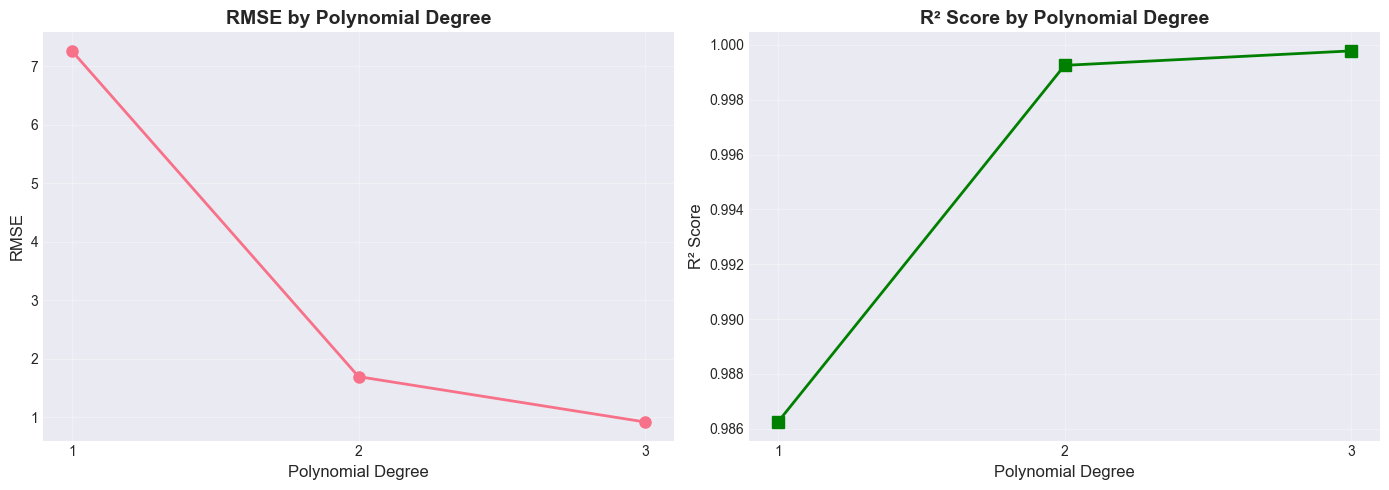


 최적 Polynomial Degree: 3
 최저 RMSE: 0.9153


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['Degree'], results_df['RMSE'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Polynomial Degree', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('RMSE by Polynomial Degree', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(results_df['Degree'])

axes[1].plot(results_df['Degree'], results_df['R²'], marker='s', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Polynomial Degree', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('R² Score by Polynomial Degree', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(results_df['Degree'])

plt.tight_layout()
plt.show()

best_idx = results_df['RMSE'].idxmin()
best_degree = results_df.loc[best_idx, 'Degree']
best_rmse = results_df.loc[best_idx, 'RMSE']

print(f"\n 최적 Polynomial Degree: {int(best_degree)}")
print(f" 최저 RMSE: {best_rmse:.4f}")

## 13. Regularization (Ridge & Lasso)

In [19]:
best_result = results[best_idx] # rmse가장 좋았던 degree 선택
poly = best_result['poly']

X_train_poly = poly.fit_transform(X_train) # 다항 학습
X_val_poly = poly.transform(X_val)

# Ridge 과적합방지
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_poly, y_train)
y_pred_ridge_log = ridge.predict(X_val_poly) # 로그 스케일 예측
y_pred_ridge = np.expm1(y_pred_ridge_log) # expm1로 원래 단위 복원
rmse_ridge = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_ridge)) # RMSE 계산

# Lasso 일부변수제거용
lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso.fit(X_train_poly, y_train)
y_pred_lasso_log = lasso.predict(X_val_poly) # 로그 스케일 예측
y_pred_lasso = np.expm1(y_pred_lasso_log) # expm1로 원래 단위 복원
rmse_lasso = np.sqrt(mean_squared_error(np.expm1(y_val), y_pred_lasso)) # RMSE 계산

print(f"Degree {int(best_degree)} + Regularization:")
print(f"  Linear: {best_rmse:.4f}")
print(f"  Ridge: {rmse_ridge:.4f}")
print(f"  Lasso: {rmse_lasso:.4f}")

model_comparison = {
    'Linear': best_rmse,
    'Ridge': rmse_ridge,
    'Lasso': rmse_lasso
}

# RMSE 가장 낮은 모델 선택
best_model_name = min(model_comparison, key=model_comparison.get)
best_model_rmse = model_comparison[best_model_name]

print(f"\n🏆 최종 최적 모델: {best_model_name} (degree={int(best_degree)})")
print(f"🏆 최종 RMSE: {best_model_rmse:.4f}")

Degree 3 + Regularization:
  Linear: 0.9153
  Ridge: 1.2100
  Lasso: 0.9406

🏆 최종 최적 모델: Linear (degree=3)
🏆 최종 RMSE: 0.9153


Linear가 제일 좋다(2599개 특성인데도 과적합 심하지 않고 구조가 정말 다항식 형태에 가까워서 그런듯)
다항 확장된 고차항을 충분히 활용해야 성능이 나오며, 규제로 계수를 줄이면 오히려 표현력이 감소하는 구조인것같다

## 14. 최종 모델 학습 (전체 Train 데이터)

In [20]:
if best_model_name == 'Ridge':
    final_model = Ridge(alpha=1.0, random_state=42)
elif best_model_name == 'Lasso':
    final_model = Lasso(alpha=0.01, random_state=42, max_iter=10000)
else:
    final_model = LinearRegression()

poly_final = PolynomialFeatures(degree=int(best_degree), include_bias=False)
train_x_poly_final = poly_final.fit_transform(train_x)
test_x_poly_final = poly_final.transform(test_x)

print(f"최종 모델 학습:")
print(f"  모델: {best_model_name}")
print(f"  Degree: {int(best_degree)}")
print(f"  특성 수: {train_x_poly_final.shape[1]}")

final_model.fit(train_x_poly_final, train_y_log)
print(f"\n✅ 학습 완료!")

최종 모델 학습:
  모델: Linear
  Degree: 3
  특성 수: 2599

✅ 학습 완료!


In [ ]:
# Test 예측 + 제출 파일
pred_test = np.clip(tpot.predict(test_x), 0, None)

submission = pd.read_csv("sample_submission.csv")
submission["Calories_Burned"] = pred_test
submission.to_csv("submit_tpot.csv", index=False)

print("✅ 저장 완료: submit_tpot.csv")
print("pred stats:", float(pred_test.min()), float(pred_test.max()), float(pred_test.mean()))

## 15. Test 데이터 예측


[반올림 적용]
범위: 1.00 ~ 309.00
평균: 89.72
Test 예측 완료!
예측값 범위: 0.93 ~ 308.95
예측값 평균: 89.72
예측값 최소값: 0.93
예측값 최대값: 308.95
원본 mean: 89.71726144838932
반올림 mean: 89.7204


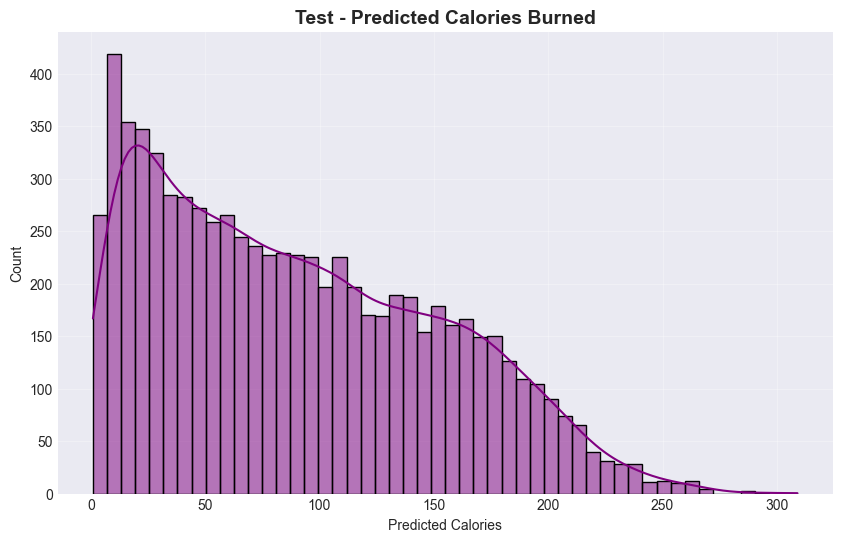

In [35]:
test_pred_log = final_model.predict(test_x_poly_final) #  train_y_log로 학습했기에 이 예측값은 log1p(Calories) 상태
test_pred = np.expm1(test_pred_log) # log1p를 썼으니까 복원은 expm1 (이제 실제 단위가 됨)

test_pred_round = np.round(test_pred) # 반올림 버전
test_pred_round = np.clip(test_pred_round, 0, None) # 혹시 음수 있으면 방지

print("\n[반올림 적용]")
print(f"범위: {test_pred_round.min():.2f} ~ {test_pred_round.max():.2f}")
print(f"평균: {test_pred_round.mean():.2f}")

print("Test 예측 완료!")
print(f"예측값 범위: {test_pred.min():.2f} ~ {test_pred.max():.2f}")
print(f"예측값 평균: {test_pred.mean():.2f}")
print(f"예측값 최소값: {test_pred.min():.2f}")
print(f"예측값 최대값: {test_pred.max():.2f}")
print("원본 mean:", test_pred.mean())
print("반올림 mean:", test_pred_round.mean())

plt.figure(figsize=(10, 6))
sns.histplot(test_pred, bins=50, kde=True, color='purple')
plt.title('Test - Predicted Calories Burned', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Calories')
plt.grid(True, alpha=0.3)
plt.show()

## 16. 제출 파일 생성

In [ ]:
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = test_pred
submission.to_csv('polynomial_regression_submit.csv', index=False)

print("✅ 제출 파일 저장: polynomial_regression_submit.csv")
display(submission.head(10))

## 17. 성능 요약

In [ ]:
print("="*70)
print("최종 모델 성능 요약")
print("="*70)
print(f" 모델: {best_model_name} + PolynomialFeatures")
print(f" Degree: {int(best_degree)}")
print(f" 원본 특성: {train_x.shape[1]}개")
print(f" 다항 특성: {train_x_poly_final.shape[1]}개")
print(f" Validation RMSE: {best_model_rmse:.4f}")
print("="*70)
print("\n 사용된 EDA 파생변수:")
print("  - Height_Total_Inches (총 키)")
print("  - Temp_diff (체온 차이)")
print("  - Duration_bin (운동시간 구간)")
print("  - Duration_x_BPM (운동강도)")
print("  - Duration_x_TempDiff (운동×체온)")
print("  - BPM_x_TempDiff (심박×체온)")
print("  - Duration_sq (운동시간 제곱)")
print("  - Temp_diff_sq (체온차이 제곱)")
print("  - Dur_BPM_TempDiff (3중 상호작용)")
print("  - BPM_per_Duration (단위시간당 심박)")
print("  - TempDiff_per_Duration (단위시간당 체온차이)")
print("  - BMI (체질량지수)")
print("  - Weight_x_Duration (체중×시간)")

## 제출 후 리더보드 점수 : 0.8941 드디ㅣ어 1점 아래로 내려왔다 ㅏㅏㅏ아ㅏㅏㅏㅏ!!!!!!